In [1]:

import pandas as pd
import numpy as np

# Load processed features and targets
X = pd.read_csv("../data/processed/features_encoded.csv")
y_regression = pd.read_csv("../data/processed/target_regression.csv").squeeze()
y_classification = pd.read_csv("../data/processed/target_classification.csv").squeeze()

# Display shapes
print("Features shape:", X.shape)
print("Regression target shape:", y_regression.shape)
print("Classification target shape:", y_classification.shape)

Features shape: (1000, 18)
Regression target shape: (1000,)
Classification target shape: (1000,)


In [2]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

# Split data for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Regression training set:", X_train_reg.shape)
print("Regression testing set:", X_test_reg.shape)
print("Classification training set:", X_train_cls.shape)
print("Classification testing set:", X_test_cls.shape)

Regression training set: (800, 18)
Regression testing set: (200, 18)
Classification training set: (800, 18)
Classification testing set: (200, 18)


In [3]:
# Import models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import cross validation
from sklearn.model_selection import cross_val_score

# Define regression models
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

# Store cross-validation results
regression_cv_results = []

# Evaluate each model using 5-fold cross-validation
for model_name, model in regression_models.items():
    
    # R2 score cross-validation
    scores = cross_val_score(
        model,
        X,
        y_regression,
        cv=5,
        scoring="r2"
    )
    
    regression_cv_results.append({
        "Model": model_name,
        "Mean R2 Score": scores.mean(),
        "Standard Deviation": scores.std()
    })

# Convert to DataFrame
regression_cv_results_df = pd.DataFrame(regression_cv_results)

regression_cv_results_df

,Model,Mean R2 Score,Standard Deviation
0,Linear Regression,0.895713,0.010335
1,Random Forest Regressor,0.853256,0.022251


In [4]:
# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define classification models
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42)
}

# Store cross-validation results
classification_cv_results = []

# Evaluate each model using 5-fold cross-validation
for model_name, model in classification_models.items():
    
    # F1 weighted cross-validation
    scores = cross_val_score(
        model,
        X,
        y_classification,
        cv=5,
        scoring="f1_weighted"
    )
    
    classification_cv_results.append({
        "Model": model_name,
        "Mean F1 Score": scores.mean(),
        "Standard Deviation": scores.std()
    })

# Convert to DataFrame
classification_cv_results_df = pd.DataFrame(classification_cv_results)

classification_cv_results_df

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,Model,Mean F1 Score,Standard Deviation
0,Logistic Regression,0.839292,0.019294
1,Decision Tree,0.694232,0.016707
2,Random Forest Classifier,0.781421,0.030213


In [5]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Define parameter grid
rf_regressor_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Create GridSearchCV object
rf_regressor_grid = GridSearchCV(
    estimator=rf_regressor,
    param_grid=rf_regressor_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train grid search
rf_regressor_grid.fit(X_train_reg, y_train_reg)

# Show best parameters
print("Best Parameters:", rf_regressor_grid.best_params_)
print("Best Cross-Validation R2 Score:", rf_regressor_grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation R2 Score: 0.8499270709293345


In [6]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get best model
best_rf_regressor = rf_regressor_grid.best_estimator_

# Predict on test data
y_pred_rf_reg = best_rf_regressor.predict(X_test_reg)

# Calculate evaluation metrics
rf_reg_mae = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_reg_r2 = r2_score(y_test_reg, y_pred_rf_reg)

print("Tuned Random Forest Regressor Performance")
print("MAE:", rf_reg_mae)
print("RMSE:", rf_reg_rmse)
print("R2 Score:", rf_reg_r2)

Tuned Random Forest Regressor Performance
MAE: 4.9612617857142824
RMSE: 6.190326786857595
R2 Score: 0.8505624114976146


In [7]:
# Define Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define parameter grid
rf_classifier_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Create GridSearchCV object
rf_classifier_grid = GridSearchCV(
    estimator=rf_classifier,
    param_grid=rf_classifier_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# Train grid search
rf_classifier_grid.fit(X_train_cls, y_train_cls)

# Show best parameters
print("Best Parameters:", rf_classifier_grid.best_params_)
print("Best Cross-Validation F1 Score:", rf_classifier_grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.7992122066985767


In [8]:
# Import classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get best model
best_rf_classifier = rf_classifier_grid.best_estimator_

# Predict on test data
y_pred_rf_cls = best_rf_classifier.predict(X_test_cls)

# Calculate metrics
rf_cls_accuracy = accuracy_score(y_test_cls, y_pred_rf_cls)
rf_cls_precision = precision_score(y_test_cls, y_pred_rf_cls, average="weighted")
rf_cls_recall = recall_score(y_test_cls, y_pred_rf_cls, average="weighted")
rf_cls_f1 = f1_score(y_test_cls, y_pred_rf_cls, average="weighted")

print("Tuned Random Forest Classifier Performance")
print("Accuracy:", rf_cls_accuracy)
print("Precision:", rf_cls_precision)
print("Recall:", rf_cls_recall)
print("F1 Score:", rf_cls_f1)

Tuned Random Forest Classifier Performance
Accuracy: 0.8
Precision: 0.8087920677545961
Recall: 0.8
F1 Score: 0.8004307713651498


In [9]:
# Extract feature importance values
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_regressor.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
1,study_hours_per_day,0.708350
7,mental_health_rating,0.106657
2,social_media_hours,0.039116
5,sleep_hours,0.037306
3,netflix_hours,0.035127
6,exercise_frequency,0.025537
4,attendance_percentage,0.020037
0,age,0.008800
11,diet_quality_Good,0.002800
8,gender_Male,0.002384


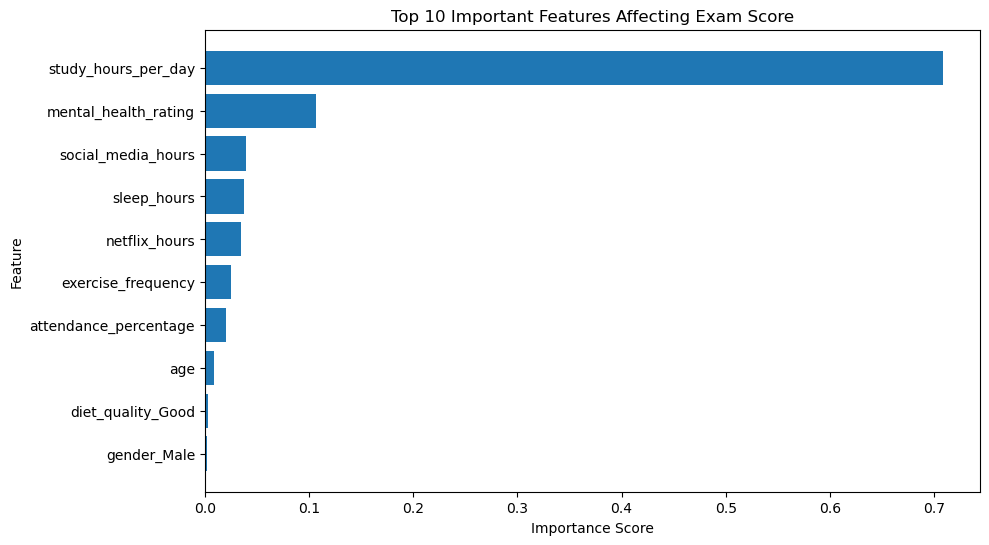

In [10]:
# Import visualization library
import matplotlib.pyplot as plt

# Select top 10 important features
top_features = feature_importance.head(10)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features Affecting Exam Score")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [11]:
# Save cross-validation results
regression_cv_results_df.to_csv(
    "../data/processed/regression_cross_validation_results.csv",
    index=False
)

classification_cv_results_df.to_csv(
    "../data/processed/classification_cross_validation_results.csv",
    index=False
)

# Save feature importance
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Improvement results saved successfully!")

Improvement results saved successfully!


In [12]:
# Import joblib for saving models
import joblib

# Save best Random Forest models
joblib.dump(
    best_rf_regressor,
    "../models/best_rf_regressor.pkl"
)

joblib.dump(
    best_rf_classifier,
    "../models/best_rf_classifier.pkl"
)

print("Best models saved successfully!")

Best models saved successfully!


In [ ]:
## Model Improvement Findings

### Tuned Random Forest Regressor

The tuned Random Forest Regressor achieved:

- MAE: 4.96
- RMSE: 6.19
- R² Score: 0.8506

Although tuning improved the model stability, Linear Regression still performed better for exam score prediction with an R² Score of 0.8965.

### Tuned Random Forest Classifier

The tuned Random Forest Classifier achieved:

- Accuracy: 80.0%
- Precision: 80.9%
- Recall: 80.0%
- F1 Score: 80.0%

However, Logistic Regression remained the best classification model with a stronger F1 Score and better cross-validation performance.

### Feature Importance Findings

The most important factor affecting exam performance was study_hours_per_day, followed by mental_health_rating, social_media_hours, sleep_hours, and netflix_hours.

This suggests that academic performance in the dataset is strongly influenced by study habits, mental well-being, and lifestyle behavior.

### Final Model Decision

- Best Regression Model: Linear Regression
- Best Classification Model: Logistic Regression
- Feature Explanation Model: Random Forest Feature Importance